# Assignment 1
**Credits**: Federico Ruggeri, Eleonora Mancini, Paolo Torroni

**Keywords**: Sexism Detection, Multi-class Classification, RNNs, Transformers, Huggingface



# Contact
For any doubt, question, issue or help, you can always contact us at the following email addresses:

Teaching Assistants:

- Federico Ruggeri -> federico.ruggeri6@unibo.it
- Eleonora Mancini -> e.mancini@unibo.it

Professor:
- Paolo Torroni -> p.torroni@unibo.it

# Introduction
You are asked to address the [EXIST 2023 Task 2](https://clef2023.clef-initiative.eu/index.php?page=Pages/labs.html#EXIST) on sexism detection.

## Problem Definition

This task aims to categorize the sexist messages according to the intention of the author in one of the following categories: (i) direct sexist message, (ii) reported sexist message and (iii) judgemental message.

### Examples:

#### DIRECT 
The intention was to write a message that is sexist by itself or incites to be sexist, as in:

''*A woman needs love, to fill the fridge, if a man can give this to her in return for her services (housework, cooking, etc), I don’t see what else she needs.*''

#### REPORTED
The intention is to report and share a sexist situation suffered by a woman or women in first or third person, as in:

''*Today, one of my year 1 class pupils could not believe he’d lost a race against a girl.*''

#### JUDGEMENTAL
The intention was to judge, since the tweet describes sexist situations or behaviours with the aim of condemning them.

''*As usual, the woman was the one quitting her job for the family’s welfare…*''

In [111]:
# Package requirements
! pip install --upgrade pip
! pip install tqdm pandas nltk gensim numpy tensorflow matplotlib scikit-learn

/Users/pelle/.zshenv:.:6: no such file or directory: /usr/local/env
/Users/pelle/.zshenv:.:6: no such file or directory: /usr/local/env


In [112]:
# Standard library
import os
import re
from collections import Counter

# Third-party libraries
import numpy as np
import pandas as pd
import gensim
import gensim.downloader as gloader
import nltk
from tqdm import tqdm
from nltk import pos_tag, word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
from tensorflow.keras.preprocessing.text import Tokenizer
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Bidirectional, LSTM, Dense, Dropout, Embedding

# Typing
from typing import List, Tuple, Set


# [Task 1 - 1.0 points] Corpus

We have preparared a small version of EXIST dataset in our dedicated [Github repository](https://github.com/lt-nlp-lab-unibo/nlp-course-material/tree/main/2025-2026/Assignment%201/data).

Check the `A1/data` folder. It contains 3 `.json` files representing `training`, `validation` and `test` sets.


### Dataset Description
- The dataset contains tweets in both English and Spanish.
- There are labels for multiple tasks, but we are focusing on **Task 2**.
- For Task 2, labels are assigned by six annotators.
- The labels for Task 2 represent whether the tweet is non-sexist ('-') or its sexist intention ('DIRECT', 'REPORTED', 'JUDGEMENTAL').







### Example

```
    "203260": {
        "id_EXIST": "203260",
        "lang": "en",
        "tweet": "ik when mandy says “you look like a whore” i look cute as FUCK",
        "number_annotators": 6,
        "annotators": ["Annotator_473", "Annotator_474", "Annotator_475", "Annotator_476", "Annotator_477", "Annotator_27"],
        "gender_annotators": ["F", "F", "M", "M", "M", "F"],
        "age_annotators": ["18-22", "23-45", "18-22", "23-45", "46+", "46+"],
        "labels_task1": ["YES", "YES", "YES", "NO", "YES", "YES"],
        "labels_task2": ["DIRECT", "DIRECT", "REPORTED", "-", "JUDGEMENTAL", "REPORTED"],
        "labels_task3": [
          ["STEREOTYPING-DOMINANCE"],
          ["OBJECTIFICATION"],
          ["SEXUAL-VIOLENCE"],
          ["-"],
          ["STEREOTYPING-DOMINANCE", "OBJECTIFICATION"],
          ["OBJECTIFICATION"]
        ],
        "split": "TRAIN_EN"
      }
    }
```

### Instructions
1. **Download** the `A1/data` folder.
2. **Load** the three JSON files and encode them as ``pandas.DataFrame``.
3. **Aggregate labels** for Task 2 using majority voting and store them in a new dataframe column called `label`. Items without a clear majority will be removed from the dataset.
4. **Filter the DataFrame** to keep only rows where the `lang` column is `'en'`.
5. **Remove unwanted columns**: Keep only `id_EXIST`, `lang`, `tweet`, and `label`.
6. **Encode the `label` column**: Use the following mapping

```
{
    '-': 0,
    'DIRECT': 1,
    'JUDGEMENTAL': 2,
    'REPORTED': 3
}
```

In [113]:
# Load and encode the jsons
train_df = pd.read_json('./data/training.json').T
test_df = pd.read_json('./data/test.json').T
val_df = pd.read_json('./data/validation.json').T
dfs = [train_df, val_df, test_df]

print("Before:", train_df.shape, val_df.shape, test_df.shape)

for i, df in enumerate(dfs):
    # Aggregate labels by majority vote, only keep rows with unique majority
    majority_labels = []
    for labels in df["labels_task2"]:
        c = Counter(labels).most_common(2)
        if len(c)==1:
            majority_labels.append(c[0][0])
        elif c[1][1] < c[0][1]:
            majority_labels.append(c[0][0])
        else:
            majority_labels.append(None)
    df["label"] = majority_labels
    df = df.dropna(subset=["label"]).reset_index(drop=True)

    # Filter rows with language "en"
    df = df[df["lang"]=="en"].reset_index(drop=True)
    df = df[["id_EXIST", "lang", "tweet", "label"]]

    # Encode labels as integers
    label_mapping = {"-":0, "DIRECT":1, "JUDGEMENTAL":2, "REPORTED":3}
    reverse_mapping = {v: k for k, v in label_mapping.items()}  # TODO: utile per debug ma togliere dopo
    df["label"] = df["label"].map(label_mapping)

    dfs[i] = df # NOTE: we have to do this otherwise the changes won't persist


train_df, val_df, test_df = dfs
print("After: ", train_df.shape, val_df.shape, test_df.shape)

Before: (6920, 11) (726, 11) (312, 11)
After:  (2873, 4) (150, 4) (280, 4)


# [Task2 - 0.5 points] Data Cleaning
In the context of tweets, we have noisy and informal data that often includes unnecessary elements like emojis, hashtags, mentions, and URLs. These elements may interfere with the text analysis.



### Instructions
- **Remove emojis** from the tweets.
- **Remove hashtags** (e.g., `#example`).
- **Remove mentions** such as `@user`.
- **Remove URLs** from the tweets.
- **Remove special characters and symbols**.
- **Remove specific quote characters** (e.g., curly quotes).
- **Perform lemmatization** to reduce words to their base form.

In [114]:

# Download required NLTK data
# NOTE: this is mostly from the lab, mayeb it's not the most efficient way
os.makedirs("nltk_data", exist_ok=True)
nltk.download('omw-1.4', download_dir="./nltk_data")
nltk.download('wordnet', download_dir="./nltk_data")
nltk.download('averaged_perceptron_tagger', download_dir="./nltk_data")
nltk.download('averaged_perceptron_tagger_eng', download_dir="./nltk_data")
nltk.download('punkt_tab', download_dir="./nltk_data")
nltk.data.path.append("./nltk_data")

lemmatizer = WordNetLemmatizer()

def pos2wordnet_tag(treebank_tag: str) -> str:
    match treebank_tag[0]:
        case "J":   return wordnet.ADJ
        case "V":   return wordnet.VERB
        case "N":   return wordnet.NOUN
        case "R":   return wordnet.ADV
        case _:     return wordnet.NOUN

def token_lemma(text: str, no_lemma: bool=False) -> str:
    """
    Tokenize the text, then lemmatize the tokens and then merge the lemmatized tokens into a text
    """
    tokens = word_tokenize(text)    # uses recommended NLTK tokenizer
    if no_lemma: 
        return " ".join(tokens)
    tagged_tokens = pos_tag(tokens)
    lemmatized_tokens = [
        lemmatizer.lemmatize(tok.lower(), pos2wordnet_tag(pos))
        for tok, pos in tagged_tokens
    ]
    return " ".join(lemmatized_tokens)

def clean_lemm_text(text, patterns, no_lemma: bool=False):
    
    # Remove other patterns
    # NOTE: we replace chars with space to avoid merging words during the process, the tokenizer will take care of extra spaces.
    for pattern in patterns:
        text = pattern.sub(' ', text) 
    
    # Tokenize, lemmatize and merge
    return token_lemma(text, no_lemma=no_lemma)

[nltk_data] Downloading package omw-1.4 to ./nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package wordnet to ./nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     ./nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     ./nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package punkt_tab to ./nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [ ]:
# NOTE: we changed the order of patterns with respect to instructions so that some could be simplified
patterns = [
    
    # Hashtags
    re.compile(r'#\w+'),
    
    # Mentions
    re.compile(r'@\w+'),
    
    # URLs
    re.compile(r'https?://[^\s]+'), 
    
    # Emojis, special characters and symbols, specific quotes characters
    # NOTE: we asked the tutors as it was ambiguous and they said they meant all non-alphanumeric characters so we merged them.
    re.compile(r'[^\s\w]')
    
]

for i, df in enumerate(dfs):
    df['cleaned_lemm_tweet'] = df["tweet"].apply(
        lambda text: clean_lemm_text(text, patterns)
    )
    
    # Useful for task 6
    df['cleaned_ony_tweet'] = df["tweet"].apply(
        lambda text: clean_lemm_text(text, patterns, no_lemma=True)
    )
    
    # TODO: only for train set, maybe apply more complex cleaning:
    # 1) remove noisy chars due to simple removal
    # 2) MAYBE: html tags, mnore complex and noisy patterns (es. 10%-)
    if i==0: 
        pass
        
    dfs[i] = df    

display(train_df[["tweet", "cleaned_lemm_tweet", "cleaned_ony_tweet"]])

,tweet,cleaned_lemm_tweet,cleaned_ony_tweet
0,FFS! How about laying the blame on the bastard...,ffs how about lay the blame on the bastard who...,FFS How about laying the blame on the bastard ...
1,Writing a uni essay in my local pub with a cof...,write a uni essay in my local pub with a coffe...,Writing a uni essay in my local pub with a cof...
2,@UniversalORL it is 2021 not 1921. I dont appr...,it be 2021 not 1921 i dont appreciate that on ...,it is 2021 not 1921 I dont appreciate that on ...
3,@GMB this is unacceptable. Use her title as yo...,this be unacceptable use her title a you do fo...,this is unacceptable Use her title as you did ...
4,‘Making yourself a harder target’ basically bo...,make yourself a hard target basically boil dow...,Making yourself a harder target basically boil...
...,...,...,...
2868,@ShefVaidya Ma'am if I say that you look like ...,ma be if i say that you look like a whore woul...,Ma am if I say that you look like a whore Woul...
2869,idk why y’all bitches think having half your a...,idk why y all bitch think have half your as ha...,idk why y all bitches think having half your a...
2870,This has been a part of an experiment with @Wo...,this have be a part of an experiment with what...,This has been a part of an experiment with Wha...
2871,"""Take me already"" ""Not yet. You gotta be ready...",take me already not yet you get ta be ready i ...,Take me already Not yet You got ta be ready I ...


In [41]:
def extract_corpus(df: pd.DataFrame) -> Tuple[List[List[str]], Set[str]]:
    # NOTE: we use split as they were already tokenized and jointed with spaces
    corpus = df["cleaned_tweet"].apply(lambda x: x.split()).tolist()
    unique_words = {word for sentence in corpus for word in sentence}
    return corpus, unique_words

# Extract corpora
train_corpus, train_words = extract_corpus(train_df)
val_corpus, val_words = extract_corpus(val_df)
test_corpus, test_words = extract_corpus(test_df)

# [Task 3 - 0.5 points] Text Encoding
To train a neural sexism classifier, you first need to encode text into numerical format.




### Instructions

* Embed words using **GloVe embeddings**.
* You are **free** to pick any embedding dimension.





### What about OOV tokens?
   * All the tokens in the **training** set that are not in GloVe **must** be added to the vocabulary.
   * For the remaining tokens (i.e., OOV in the validation and test sets), you have to assign them a **special token** (e.g., ``<UNK>``) and a **static** embedding.
   * You are **free** to define the static embedding using any strategy (e.g., random, neighbourhood, etc...)



### More about OOV

For a given token:

* **If in train set**: add to vocabulary and assign an embedding (use GloVe if token in GloVe, custom embedding otherwise).
* **If in val/test set**: assign special token if not in vocabulary and assign custom embedding.

Your vocabulary **should**:

* Contain all tokens in train set; or
* Union of tokens in train set and in GloVe $\rightarrow$ we make use of existing knowledge!

In [100]:
# Hyperparams
USE_FULL_PRELOAD_EMB_MODEL = False
EMBEDDING_DIMENSION = 50
OOV_TOKEN = "<OOV>"
SEED=42

In [101]:
# FUNCTIONS

def load_embedding_model(
    model_type: str,
    embedding_dimension: int = 50
) -> gensim.models.keyedvectors.KeyedVectors:
    
    """
    Load pre-trained embedding model (Word2Vec, GloVe, FastText).

    :param model_type: 'word2vec', 'glove', or 'fasttext'
    :param embedding_dimension: embedding size (only used for GloVe)
    :return: gensim KeyedVectors object
    """
    
    types = {
        "word2vec" : "word2vec-google-news-300",
        "glove" : f"glove-wiki-gigaword-{embedding_dimension}",
        "fasttext" : "fasttext-wiki-news-subwords-300"
    }
    
    model_type_lower = model_type.strip().lower()
    if model_type_lower not in types.keys():
        raise ValueError(f"Unsupported embedding model type. Use {', '.join(list(types.keys()))}")
    else:
        path = types[model_type_lower]
        
    try:
        return gloader.load(path)
    except ValueError as e:
        raise ValueError("Failed to load embedding. Check dimension compatibility.") from e
        
def build_tokenizer(
    train_words: Set[str] = None,
    embedding_model: gensim.models.keyedvectors.KeyedVectors = None,
    use_full_embed_model: bool = True,
    oov_token: str = "<OOV>",
    verbose: bool = False
) -> Tokenizer:
    """
    Build a Keras tokenizer from a corpus of tokenized sentences.
    
    :param train_words: set of words in training corpus (used when use_full_embed_model=False)
    :param embedding_model: pre-trained embedding model (used when use_full_embed_model=True)
    :param use_full_embed_model: if True, use all words from corpus + embedding_model; if False, only train_words
    :param oov_token: token for out-of-vocabulary words
    :param verbose: print statistics
    :return: fitted Tokenizer
    """
    
    assert isinstance(train_words, set), "train_words must be a set of strings"
    
    # Determine which words to keep
    embedding_words = set(embedding_model.index_to_key)
    if use_full_embed_model:
        # Use all words from embedding model and training corpus
        vocab_to_use = train_words | embedding_words  # Union
    else:
        # Only use training words
        vocab_to_use = train_words
    
    # Build tokenizer
    # NOTE: we load the glove tokens as they are (with punctuation, case-sensitive)
    tokenizer = Tokenizer(
        oov_token=oov_token,
        filters='',           
        lower=False,          
        split=' '             
    )
    tokenizer.fit_on_texts(list(vocab_to_use))
    
    if verbose and not use_full_embed_model:
        print(f"Tokenizer doesn't contain {len(embedding_words - train_words)} words from the embedding model (they were not in the train set).")
    
    return tokenizer

def build_embedding_matrix(
    tokenizer: Tokenizer,
    embedding_model: gensim.models.keyedvectors.KeyedVectors,
    seed: int = 42,
    verbose: bool = True
) -> tuple[np.ndarray, list]:
    """
    Build embedding matrix from tokenizer vocabulary and embedding model.
    
    Index 0: padding (zeros)
    Other indices: 
        - If word in embedding_model: use pre-trained embedding
        - Otherwise: random embedding based on distribution of train_words in model
    
    :param tokenizer: fitted Keras tokenizer
    :param embedding_model: pre-loaded embedding model (unchanged)
    :param train_words: set of words in training corpus (for computing random embedding distribution)
    :param seed: random seed for reproducibility
    :param verbose: whether to print detailed statistics
    :return: tuple of (embedding_matrix, random_idxs)
             embedding_matrix: shape (vocab_size, embedding_dim)
             random_idxs: list of indices that got random embeddings
    """
    vocab_size = len(tokenizer.word_index) + 1
    embedding_dim = embedding_model.vector_size
    
    # Initialize with zeros
    embedding_matrix = np.zeros((vocab_size, embedding_dim))
    
    # Pre-compute parameters for random embeddings
    # ALWAYS use distribution from the tokenizer (only train or train|model)
    filtered_vectors = np.array([
        embedding_model[word] for word in tokenizer.word_index.keys() 
        if word in embedding_model
    ])
    mean = filtered_vectors.mean(axis=0)
    std = filtered_vectors.std(axis=0)

    # Statistics tracking
    from_model_count = 0
    random_idxs = []  # indices that received random embeddings
    
    # Set random seed for reproducibility
    np.random.seed(seed)
    
    # Fill embedding matrix with progress bar
    for word, idx in tqdm(tokenizer.word_index.items(), 
                          desc="Building embedding matrix",
                          disable=not verbose):
        if word in embedding_model:
            # Use pre-trained embedding
            embedding_matrix[idx] = embedding_model[word]
            from_model_count += 1
        else:
            # OOV word: use random embedding
            embedding_matrix[idx] = np.random.normal(mean, std)
            random_idxs.append(idx)
    
    if verbose:
        total_words = vocab_size - 1  # excluding padding
        coverage = from_model_count / total_words * 100 if total_words > 0 else 0
        
        print(f"Embedding Matrix Statistics:")
        print(f"\tShape: {embedding_matrix.shape}")
        print(f"\tWords from embedding model: {from_model_count}/{total_words} ({coverage:.2f}%)")
        print(f"\tRandom embeddings (OOV): {len(random_idxs)}")
    
    return embedding_matrix, random_idxs

In [102]:
# Load embedding model
embedding_model = load_embedding_model("glove", EMBEDDING_DIMENSION)
print(f"Embedding model length: {len(embedding_model.index_to_key)}\n")

# Build tokenizer
tokenizer = build_tokenizer(
    train_words=train_words,
    embedding_model=embedding_model,
    use_full_embed_model=USE_FULL_PRELOAD_EMB_MODEL,
    oov_token=OOV_TOKEN,
    verbose=True
)
vocab_size = len(tokenizer.word_index) + 1 # +1 for padding at index 0
print(f"Final vocabulary size: {vocab_size}\n")

# Build embedding matrix
embedding_matrix, random_idxs = build_embedding_matrix(
    tokenizer=tokenizer,
    embedding_model=embedding_model,
    seed=SEED,
    verbose=True
)

Embedding model length: 400000

Tokenizer doesn't contain 391818 words from the embedding model (they were not in the train set).
Final vocabulary size: 9146



Building embedding matrix: 100%|██████████| 9145/9145 [00:00<00:00, 106040.04it/s]

Embedding Matrix Statistics:
	Shape: (9146, 50)
	Words from embedding model: 8182/9145 (89.47%)
	Random embeddings (OOV): 963


## Extra: statistics of OOV in val and test sets

In [103]:
def compute_oov_stats(tokenizer, word_set, set_name):
    """
    Compute out-of-vocabulary statistics for a given word set.
    
    :param tokenizer: fitted Keras tokenizer
    :param word_set: set of words to check
    :param set_name: name of the dataset (for display)
    """
    tokenizer_vocab = set(tokenizer.word_index.keys())
    
    oov_words = word_set - tokenizer_vocab
    in_vocab_words = word_set & tokenizer_vocab
    
    total = len(word_set)
    oov_count = len(oov_words)
    in_vocab_count = len(in_vocab_words)
    oov_rate = (oov_count / total * 100) if total > 0 else 0
    
    print(f"{set_name} OOV Statistics:")
    print(f"\tTotal unique words: {total}")
    print(f"\tIn vocabulary: {in_vocab_count} ({100 - oov_rate:.2f}%)")
    print(f"\tOOV words: {oov_count} ({oov_rate:.2f}%)")
    print()
    
compute_oov_stats(tokenizer, train_words, "Training Set")
compute_oov_stats(tokenizer, val_words, "Validation Set")
compute_oov_stats(tokenizer, test_words, "Test Set")

Training Set OOV Statistics:
	Total unique words: 9144
	In vocabulary: 9144 (100.00%)
	OOV words: 0 (0.00%)

Validation Set OOV Statistics:
	Total unique words: 1456
	In vocabulary: 1143 (78.50%)
	OOV words: 313 (21.50%)

Test Set OOV Statistics:
	Total unique words: 2124
	In vocabulary: 1593 (75.00%)
	OOV words: 531 (25.00%)



## Extra: visualization of embedding

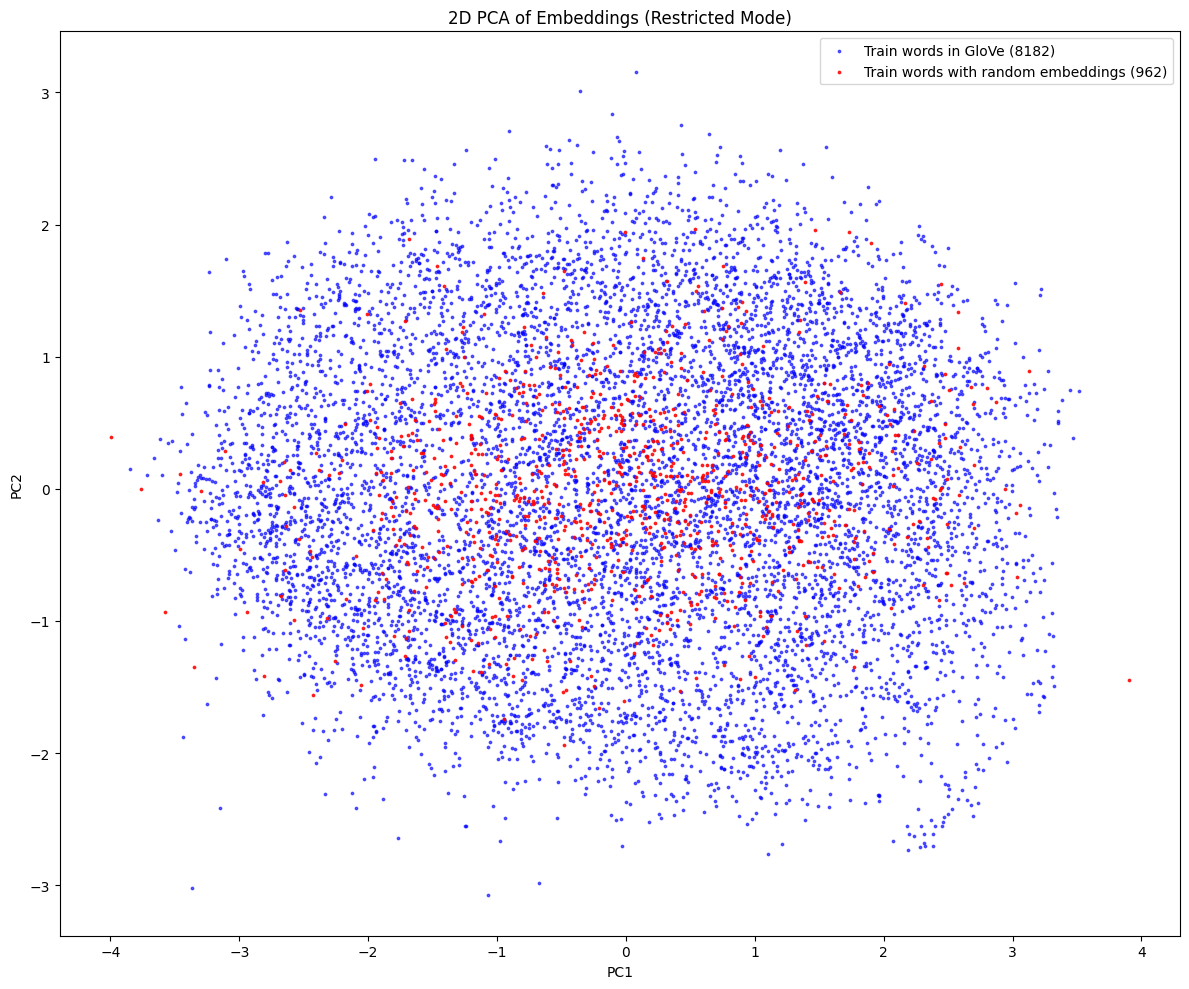

In [104]:
embedding_vocab = set(embedding_model.index_to_key)
train_vocab = set(train_words)

if USE_FULL_PRELOAD_EMB_MODEL:
    # Full-preload mode: visualize all words in tokenizer with category distinctions
    
    # Get all words from tokenizer
    tokenizer_words = set(tokenizer.word_index.keys())
    
    # Categorize based on origin
    cat_train_in_embed = list(train_vocab & embedding_vocab)        # Train words with GloVe embeddings
    cat_embed_only = list((tokenizer_words & embedding_vocab) - train_vocab)  # GloVe words not in train
    cat_train_random = list(train_vocab - embedding_vocab)          # Train words with random embeddings
    
    # Collect embedding vectors for each category
    embed_train_in_embed = np.array([embedding_matrix[tokenizer.word_index[t]] for t in cat_train_in_embed])
    embed_embed_only = np.array([embedding_matrix[tokenizer.word_index[t]] for t in cat_embed_only])
    embed_train_random = np.array([embedding_matrix[tokenizer.word_index[t]] for t in cat_train_random])
    
    # Combine all vectors for PCA
    all_embeddings = np.concatenate([embed_train_in_embed, embed_embed_only, embed_train_random], axis=0)
    pca = PCA(n_components=2)
    all_2d = pca.fit_transform(all_embeddings)
    
    # Split projected coordinates by category
    n_train_in_embed = len(embed_train_in_embed)
    n_embed_only = len(embed_embed_only)
    n_train_random = len(embed_train_random)
    
    coords_train_in_embed = all_2d[:n_train_in_embed]
    coords_embed_only = all_2d[n_train_in_embed:n_train_in_embed + n_embed_only]
    coords_train_random = all_2d[n_train_in_embed + n_embed_only:]
    
    # Plot each category
    plt.figure(figsize=(12, 10))
    plt.scatter(coords_train_in_embed[:, 0], coords_train_in_embed[:, 1], s=3, alpha=0.6, color="blue",
                label=f"Train words in GloVe ({len(cat_train_in_embed)})")
    plt.scatter(coords_embed_only[:, 0], coords_embed_only[:, 1], s=3, alpha=0.4, color="green",
                label=f"GloVe words not in train ({len(cat_embed_only)})")
    plt.scatter(coords_train_random[:, 0], coords_train_random[:, 1], s=3, alpha=0.8, color="red",
                label=f"Train words with random embeddings ({len(cat_train_random)})")
    
    plt.title("2D PCA of Embeddings (Full Model Mode)")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.tight_layout()
    plt.show()

else:
    # Restricted mode: only train words are in tokenizer
    
    # Get all words from tokenizer (should be only train_vocab)
    tokenizer_words = set(tokenizer.word_index.keys())
    
    # Categorize based on whether they have GloVe embeddings or random ones
    cat_train_in_embed = list(train_vocab & embedding_vocab)    # Train words with GloVe embeddings
    cat_train_random = list(train_vocab - embedding_vocab)      # Train words with random embeddings

    # Collect embedding vectors for each category
    embed_train_in_embed = np.array([embedding_matrix[tokenizer.word_index[t]] for t in cat_train_in_embed])
    embed_train_random = np.array([embedding_matrix[tokenizer.word_index[t]] for t in cat_train_random])

    # Combine all vectors for PCA
    all_embeddings = np.concatenate([embed_train_in_embed, embed_train_random], axis=0)
    pca = PCA(n_components=2)
    all_2d = pca.fit_transform(all_embeddings)

    # Split projected coordinates by category
    n_train_in_embed = len(embed_train_in_embed)
    n_train_random = len(embed_train_random)

    coords_train_in_embed = all_2d[:n_train_in_embed]
    coords_train_random = all_2d[n_train_in_embed:]

    # Plot each category
    plt.figure(figsize=(12, 10))
    plt.scatter(coords_train_in_embed[:, 0], coords_train_in_embed[:, 1], s=3, alpha=0.6, color="blue",
                label=f"Train words in GloVe ({len(cat_train_in_embed)})")
    plt.scatter(coords_train_random[:, 0], coords_train_random[:, 1], s=3, alpha=0.8, color="red",
                label=f"Train words with random embeddings ({len(cat_train_random)})")

    plt.title("2D PCA of Embeddings (Restricted Mode)")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.tight_layout()
    plt.show()

# [Task 4 - 1.0 points] Model definition

You are now tasked to define your sexism classifier.




### Instructions

* **Baseline**: implement a Bidirectional LSTM with a Dense layer on top.

* **Stacked**: add an additional Bidirectional LSTM layer to the Baseline model.

**Note**: You are **free** to experiment with hyper-parameters.

In [106]:
NUM_CLASSES = len(label_mapping.keys())
MAX_SEQ_LEN = max([df['cleaned_tweet'].apply(lambda x: len(x.split())).max() for df in dfs])

# NOTE: la struttura potrebbe essere too much ma visto che con ipcv ci eravamo trovati "bene" a testarla l'ho riproposta
hyperparams_models = {
    "baseline": {
        "model": {
            "lstm_units": 256,
            "dense_units": 32,
            "dropout_rate": 0.3,   
        },
        "train": {}
    },
    "stacked": {
        "model": {
            "lstm_units_1": 256,
            "lstm_units_2": 256,
            "dense_units": 32,
            "dropout_rate_1": 0.3,
            "dropout_rate_2": 0.3,
        },
        "train": {}
    }
}

### Token to embedding mapping

You can follow two approaches for encoding tokens in your classifier.

### Work directly with embeddings

- Compute the embedding of each input token
- Feed the mini-batches of shape ``(batch_size, # tokens, embedding_dim)`` to your model

### Work with Embedding layer

- Encode input tokens to token ids
- Define a Embedding layer as the first layer of your model
- Compute the embedding matrix of all known tokens (i.e., tokens in your vocabulary)
- Initialize the Embedding layer with the computed embedding matrix
- You are **free** to set the Embedding layer trainable or not

In [ ]:
models = {
    "baseline" : Sequential([
        Input(shape=(MAX_SEQ_LEN,)),
        Embedding(
            input_dim=vocab_size, 
            output_dim=EMBEDDING_DIMENSION,
            weights=[embedding_matrix],
            mask_zero=True,
            name='encoder_embedding'
        ),
        Bidirectional(LSTM(
            units=hyperparams_models["baseline"]["model"]["lstm_units"],
            return_sequences=False
        )),
        Dropout(hyperparams_models["baseline"]["model"]["dropout_rate"]),
        Dense(
            units=hyperparams_models["baseline"]["model"]["dense_units"],
            activation='relu'
        ),
        Dense(units=NUM_CLASSES, activation='softmax')
    ], name="baseline_bidirectional_lstm"),
    
    "stacked" : Sequential([
        Input(shape=(MAX_SEQ_LEN,)),
        Embedding(
            input_dim=vocab_size,
            output_dim=EMBEDDING_DIMENSION,
            weights=[embedding_matrix],
            mask_zero=True,
            name='encoder_embedding'
        ),
        Bidirectional(LSTM(
            units=hyperparams_models["stacked"]["model"]["lstm_units_1"],
            return_sequences=True  # NOTE: return sequences for stacking
        )),
        Dropout(hyperparams_models["stacked"]["model"]["dropout_rate_1"]),
        Bidirectional(LSTM(
            units=hyperparams_models["stacked"]["model"]["lstm_units_2"],
            return_sequences=False
        )),
        Dropout(hyperparams_models["stacked"]["model"]["dropout_rate_2"]),
        Dense(
            units=hyperparams_models["stacked"]["model"]["dense_units"],
            activation='relu'
        ),
        Dense(units=NUM_CLASSES, activation='softmax')
    ], name="stacked_bidirectional_lstm")
}

In [110]:
for model_name, model in models.items():
    model.summary()
    print("*"*100, "\n")

Model: "baseline_bidirectional_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_embedding (Embedding)   │ (None, 63, 50)         │       457,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 512)            │       628,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │        16,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,102,584 (4.21 MB)

 Trainable params: 1,102,584 (4.21 MB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_embedding (Embedding)   │ (None, 63, 50)         │       457,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 63, 512)        │       628,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 63, 512)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 512)            │     1,574,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │        16,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,677,496 (10.21 MB)

 Trainable params: 2,677,496 (10.21 MB)

 Non-trainable params: 0 (0.00 B)

**************************************************************************************************** 



# [Task 5 - 1.0 points] Training and Evaluation

You are now tasked to train and evaluate the Baseline and Stacked models.



### Instructions

* Pick **at least** three seeds for robust estimation.
* Train **all** models on the train set.
* Evaluate **all** models on the validation and test sets.
* Compute macro F1-score, precision, and recall metrics on the validation set.
* Report average and standard deviation measures over seeds for each metric.
* Pick the **best** performing model according to the observed validation set performance (use macro F1-score).

# [Task 6 - 1.0 points] Transformers

In this section, you will use a transformer model specifically trained for hate speech detection, namely [Twitter-roBERTa-base for Hate Speech Detection](https://huggingface.co/cardiffnlp/twitter-roberta-base-hate).




### Relevant Material
- Tutorial 3

### Instructions
- **Load the Tokenizer and Model**

- **Preprocess the Dataset**:
   You will need to preprocess your dataset to prepare it for input into the model. Tokenize your text data using the appropriate tokenizer and ensure it is formatted correctly.

- **Train the Model**:
   Use the `Trainer` to train the model on your training data.

- **Evaluate the Model on the Test Set** using the same metrics used for LSTM-based models.

# [Task 7 - 0.5 points] Error Analysis

After evaluating the model, perform a brief error analysis on the **test set**:

### Instructions

 - Review the results and identify common errors.

 - Summarize your findings regarding the errors and their impact on performance (e.g. but not limited to Out-of-Vocabulary (OOV) words, data imbalance, and performance differences between the custom model and the transformer...)
 - Suggest possible solutions to address the identified errors.

# [Task 8 - 0.5 points] Report

Wrap up your experiment in a short report (up to 2 pages).

### Instructions

* Use the NLP course report template.
* Summarize each task in the report following the provided template.

### Recommendations

The report is **not a copy-paste** of graphs, tables, and command outputs.

* Summarize classification performance in Table format.
* **Do not** report command outputs or screenshots.
* Report learning curves in Figure format.
* The error analysis section should summarize your findings.


# Submission

* **Submit** your report in PDF format.
* **Submit** your python notebook.
* Make sure your notebook is **well organized**, with no temporary code, commented sections, tests, etc...
* You can upload **model weights** in a cloud repository and report the link in the report.

## Bonus Points
Bonus points are arbitrarily assigned based on significant contributions such as:
- Outstanding error analysis
- Masterclass code organization
- Suitable extensions

**Note**: bonus points are only assigned if all task points are attributed (i.e., 6/6).

**Possible Suggestions for Bonus Points:**
- **Try other preprocessing strategies**: e.g., but not limited to, explore techniques tailored specifically for tweets or  methods that are common in social media text.
- **Experiment with other custom architectures or models from HuggingFace**
- **Explore Spanish tweets**: e.g., but not limited to, leverage multilingual models to process Spanish tweets and assess their performance compared to monolingual models.

# FAQ

Please check this frequently asked questions before contacting us

### Trainable Embeddings

You are **free** to define a trainable or non-trainable Embedding layer to load the GloVe embeddings.

### Model architecture

You **should not** change the architecture of a model (i.e., its layers).

However, you are **free** to play with their hyper-parameters.


### Neural Libraries

You are **free** to use any library of your choice to implement the networks (e.g., Keras, Tensorflow, PyTorch, JAX, etc...)

### Robust Evaluation

Each model is trained with at least 3 random seeds.

Task 5 requires you to compute the average performance over the 3 seeds and its corresponding standard deviation.

### Expected Results

Task 2 leaderboard reports around 40-50 F1-score.
However, note that they perform a hierarchical classification.

That said, results around 30-40 F1-score are **expected** given the task's complexity.

### Model Selection for Analysis

To carry out the error analysis you are **free** to either

* Pick examples or perform comparisons with an individual seed run model (e.g., Baseline seed 1337)
* Perform ensembling via, for instance, majority voting to obtain a single model.

### Error Analysis

Some topics for discussion include:
   * Precision/Recall curves.
   * Confusion matrices.
   * Specific misclassified samples.


# The End

Feel free to reach out for questions/doubts!